# 3-Client Federe Öğrenme — Model Poisoning & Savunma
**Zehirli Client:** C2 (IoMT Ana — MQTT %85)  
**Savunma 1:** Trimmed Mean (trim_ratio=0.34)  
**Savunma 2:** FedMedian (koordinat-bazlı medyan)

In [ ]:
# =============================================================================
# BLOK 0-A — ORTAM KURULUMU, DRIVE BAGLANTISI, MODEL MIMARISI
# 3-CLIENT MODEL POISONING & SAVUNMA
# Zehirli client  : C2 (IoMT Ana — MQTT %85)
# Savunma 1       : Trimmed Mean (trim_ratio=0.34 → her uctan 1 kirp, 1 kalan)
# Savunma 2       : FedMedian (3 client icin daha guclu)
# =============================================================================

import os, gc, math, time, joblib
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import mixed_precision
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Dropout, LayerNormalization,
    MultiHeadAttention, Add, TimeDistributed, Conv1D,
    Bidirectional, Lambda
)
from google.colab import drive

print("=" * 65)
print("   BLOK 0-A: ORTAM KURULUMU (3 CLIENT POISON & SAVUNMA)")
print("=" * 65)

# Drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')
print("OK Google Drive baglandi")

# GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    det = tf.config.experimental.get_device_details(gpus[0])
    gpu_name = det.get('device_name', 'Bilinmiyor')
    print(f"OK GPU: {gpu_name}")
    if 'H100' in gpu_name or 'A100' in gpu_name:
        mixed_precision.set_global_policy('mixed_bfloat16')
        tf.config.optimizer.set_jit(True)
        print("OK Mixed Precision: bfloat16 | XLA: AKTIF")
    else:
        mixed_precision.set_global_policy('float32')
        print("OK Precision: float32")
else:
    print("UYARI GPU bulunamadi — CPU ile devam ediliyor")

# Global Sabitler
ROOT_PATH   = '/content/drive/MyDrive/wifi_mqtt'
TRAIN_DIR   = '/content/drive/MyDrive/federe3Client'
SAVE_DIR    = '/content/drive/MyDrive/federe3Client'
RESULTS_DIR = f'{SAVE_DIR}/poison_savunma_sonuclari'
MODEL_PATH  = f'{TRAIN_DIR}/federe_mha_lstm_best.keras'

os.makedirs(RESULTS_DIR, exist_ok=True)
print(f"OK Cikti klasoru olusturuldu: {RESULTS_DIR}")

TIME_STEPS    = 20
PCA_VARIANCE  = 0.95
SEED          = 42
TEST_SIZE     = 0.20
BATCH_SIZE    = 512
LEARNING_RATE = 0.001
NUM_CLIENTS   = 3

np.random.seed(SEED)
tf.random.set_seed(SEED)

# NaN-Safe Loss (3-client egitim notebookundan birebir)
def combined_reconstruction_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    mae = tf.reduce_mean(tf.abs(y_true - y_pred))
    mse = tf.reduce_mean(tf.square(y_true - y_pred))
    return 0.6 * mae + 0.4 * mse

# Transformer Bloku (3-client egitim notebookundan birebir)
def transformer_encoder_block(x, embed_dim, num_heads, ff_dim,
                               dropout_rate, name_prefix=""):
    attn_input  = LayerNormalization(epsilon=1e-5, name=f"{name_prefix}_ln1")(x)
    attn_output = MultiHeadAttention(
        num_heads=num_heads, key_dim=embed_dim // num_heads,
        dropout=dropout_rate, name=f"{name_prefix}_mha"
    )(attn_input, attn_input)
    x = Add(name=f"{name_prefix}_add1")([x, attn_output])
    ff_input  = LayerNormalization(epsilon=1e-5, name=f"{name_prefix}_ln2")(x)
    ff_output = Dense(ff_dim, activation='relu', name=f"{name_prefix}_ff1")(ff_input)
    ff_output = Dropout(dropout_rate, name=f"{name_prefix}_drop")(ff_output)
    ff_output = Dense(embed_dim, name=f"{name_prefix}_ff2")(ff_output)
    x = Add(name=f"{name_prefix}_add2")([x, ff_output])
    return x

# Model Mimarisi (3-client egitim notebookundan birebir)
def build_model(time_steps, pca_components):
    inputs = Input(shape=(time_steps, pca_components), dtype='float32', name='input')
    # ENCODER
    x = Conv1D(64, kernel_size=3, padding='same', activation='relu',
               name='conv_local')(inputs)
    x = Bidirectional(
        LSTM(128, return_sequences=True, activation='tanh',
             kernel_initializer='glorot_uniform',
             recurrent_initializer='orthogonal'),
        name='bilstm_encoder'
    )(x)
    x = Dropout(0.15, name='drop_enc_1')(x)
    x = transformer_encoder_block(x, embed_dim=256, num_heads=4, ff_dim=512,
                                   dropout_rate=0.1, name_prefix="enc_transformer")
    encoder_out = LSTM(64, return_sequences=True, activation='tanh',
                       kernel_initializer='glorot_uniform',
                       recurrent_initializer='orthogonal',
                       name='bottleneck')(x)
    encoder_out = LayerNormalization(epsilon=1e-5, name='bottleneck_ln')(encoder_out)
    x = transformer_encoder_block(encoder_out, embed_dim=64, num_heads=4,
                                   ff_dim=128, dropout_rate=0.1,
                                   name_prefix="bottleneck_transformer")
    # DECODER
    x = LSTM(128, return_sequences=True, activation='tanh',
             kernel_initializer='glorot_uniform',
             recurrent_initializer='orthogonal', name='lstm_dec_1')(x)
    x = Dropout(0.15, name='drop_dec_1')(x)
    x = transformer_encoder_block(x, embed_dim=128, num_heads=4, ff_dim=256,
                                   dropout_rate=0.1, name_prefix="dec_transformer")
    x = LSTM(256, return_sequences=True, activation='tanh',
             kernel_initializer='glorot_uniform',
             recurrent_initializer='orthogonal', name='lstm_dec_2')(x)
    x = Dropout(0.1, name='drop_dec_2')(x)
    x = TimeDistributed(Dense(pca_components), name='output_dense')(x)
    outputs = Lambda(lambda t: tf.cast(t, tf.float32), name='output_cast')(x)
    model = Model(inputs=inputs, outputs=outputs,
                  name='Federe_MHA_LSTM_Autoencoder_3Client')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=LEARNING_RATE, clipvalue=0.5, epsilon=1e-7
        ),
        loss=combined_reconstruction_loss
    )
    return model

print("\nOK build_model() tanimlandi (3-client egitim mimarisiyle birebir)")
print("\n" + "=" * 65)
print("   BLOK 0-A TAMAMLANDI — BLOK 0-B'YE GECIN")
print("=" * 65)

   BLOK 0-A: ORTAM KURULUMU (3 CLIENT POISON & SAVUNMA)
Mounted at /content/drive
OK Google Drive baglandi
OK GPU: NVIDIA A100-SXM4-40GB
OK Mixed Precision: bfloat16 | XLA: AKTIF
OK Cikti klasoru olusturuldu: /content/drive/MyDrive/federe3Client/poison_savunma_sonuclari

OK build_model() tanimlandi (3-client egitim mimarisiyle birebir)

   BLOK 0-A TAMAMLANDI — BLOK 0-B'YE GECIN


In [ ]:
# =============================================================================
# BLOK 0-B — SCALER/PCA/MODEL YUKLEME + 3 CLIENT DATASETS + X_normal/X_attack
# =============================================================================

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, confusion_matrix,
    ConfusionMatrixDisplay
)

print("=" * 65)
print("   BLOK 0-B: DRIVE'DAN YUKLEME + 3-CLIENT VERI HAZIRLAMA")
print("=" * 65)

# 1. Scaler ve PCA (3-client egitiminde kaydedilen)
scaler_path = f'{TRAIN_DIR}/federe_mha_scaler.pkl'
pca_path    = f'{TRAIN_DIR}/federe_mha_pca.pkl'

if os.path.exists(scaler_path) and os.path.exists(pca_path):
    scaler = joblib.load(scaler_path)
    pca    = joblib.load(pca_path)
    PCA_COMPONENTS  = pca.n_components_
    FEATURE_COLUMNS = list(scaler.feature_names_in_)
    print(f"OK Scaler yuklendi — {len(FEATURE_COLUMNS)} ozellik")
    print(f"OK PCA yuklendi   — {PCA_COMPONENTS} bilesen")
else:
    raise FileNotFoundError(
        f"Scaler/PCA bulunamadi: {scaler_path}\n"
        "3-client egitim notebookunu once calistirin."
    )

# 2. Normal veriden 3-client bolunmesi (3-client egitimiyle birebir)
print("\n Normal (profiling) dosyalari taranıyor...")

all_benign_files = []
for root, dirs, files in os.walk(ROOT_PATH):
    for file in files:
        if file.endswith(".csv") and 'profiling' in root.lower():
            all_benign_files.append(os.path.join(root, file))

print(f"   {len(all_benign_files)} dosya bulundu")

wifi_files, mqtt_files = [], []
for f in all_benign_files:
    fname = os.path.basename(f).lower()
    if 'mqtt' in fname:
        mqtt_files.append(f)
    else:
        wifi_files.append(f)

if len(mqtt_files) < 2:
    print("   UYARI: Isimden MQTT ayrimi yapilamadi, dosyalar rastgele bolunuyor...")
    mid = len(all_benign_files) // 2
    wifi_files = all_benign_files[:mid]
    mqtt_files = all_benign_files[mid:]

print(f"   WiFi dosya: {len(wifi_files)} | MQTT dosya: {len(mqtt_files)}")

def load_client_df(file_list):
    dfs = []
    for f in file_list:
        try:
            df = pd.read_csv(f)
            df = df.select_dtypes(include=[np.number]).astype('float32')
            df.replace([np.inf, -np.inf], np.nan, inplace=True)
            df.dropna(inplace=True)
            for col in set(FEATURE_COLUMNS) - set(df.columns):
                df[col] = 0.0
            df = df[FEATURE_COLUMNS]
            dfs.append(df)
        except:
            pass
    return pd.concat(dfs, ignore_index=True)

df_wifi_all = load_client_df(wifi_files)
df_mqtt_all = load_client_df(mqtt_files)
print(f"   WiFi havuzu: {df_wifi_all.shape} | MQTT havuzu: {df_mqtt_all.shape}")

# 3-client Non-IID bolunme (3-client egitimiyle birebir)
# WiFi: C1 %85 Ana + leftover
w_cut = int(len(df_wifi_all) * 0.85)
df_c1 = df_wifi_all.iloc[:w_cut]
wifi_leftover = df_wifi_all.iloc[w_cut:]

# MQTT: C2 %85 Ana + leftover
m_cut = int(len(df_mqtt_all) * 0.85)
df_c2 = df_mqtt_all.iloc[:m_cut]
mqtt_leftover = df_mqtt_all.iloc[m_cut:]

# Karma: C3
df_c3 = pd.concat([wifi_leftover, mqtt_leftover], ignore_index=True)

client_dfs = [
    (df_c1, "C1_Hastane"),
    (df_c2, "C2_IoMT_Ana"),
    (df_c3, "C3_Ambulans"),
]
del df_wifi_all, df_mqtt_all; gc.collect()

print(f"\n{'Client':<18} {'Satir':>10} {'Kolon':>7}")
print("-" * 38)
for df, name in client_dfs:
    print(f"  {name:<16}: {df.shape[0]:>8,}  {df.shape[1]:>6}")

def create_sequences_fast(data, time_steps):
    n       = data.shape[0] - time_steps
    shape   = (n, time_steps, data.shape[1])
    strides = (data.strides[0], data.strides[0], data.strides[1])
    return np.array(
        np.lib.stride_tricks.as_strided(data, shape=shape, strides=strides),
        dtype=np.float32
    )

AUTOTUNE = tf.data.AUTOTUNE

def make_client_dataset(df, name):
    scaled = scaler.transform(df).astype(np.float32)
    pca_t  = pca.transform(scaled).astype(np.float32)
    seqs   = create_sequences_fast(pca_t, TIME_STEPS)
    split  = int(len(seqs) * (1 - TEST_SIZE))
    X_tr, X_val = seqs[:split], seqs[split:]
    train_ds = (
        tf.data.Dataset.from_tensor_slices((X_tr, X_tr))
        .cache().shuffle(15000, seed=SEED)
        .batch(BATCH_SIZE, drop_remainder=True).prefetch(AUTOTUNE)
    )
    val_ds = (
        tf.data.Dataset.from_tensor_slices((X_val, X_val))
        .cache().batch(BATCH_SIZE, drop_remainder=False).prefetch(AUTOTUNE)
    )
    print(f"   [{name:<14}] train={len(X_tr):>8,} | val={len(X_val):>7,}")
    return {"name": name, "train": train_ds, "val": val_ds,
            "n_train": len(X_tr), "n_val": len(X_val)}

print("\n 3 Client pipeline'lari olusturuluyor...")
CLIENT_DATASETS = []
for df, name in client_dfs:
    CLIENT_DATASETS.append(make_client_dataset(df, name))
del client_dfs; gc.collect()

# Baseline model (3-client egitimi)
print(f"\n 3-client modeli yukleniyor: {MODEL_PATH}")
tf.keras.backend.clear_session(); gc.collect()
baseline_model = build_model(TIME_STEPS, PCA_COMPONENTS)
baseline_model.load_weights(MODEL_PATH)
print(f"OK Baseline model yuklendi — {baseline_model.count_params():,} parametre")

INITIAL_WEIGHTS = [w.copy() for w in baseline_model.get_weights()]
joblib.dump(INITIAL_WEIGHTS, f'{RESULTS_DIR}/initial_weights_3client.pkl')
print(f"OK INITIAL_WEIGHTS saklandı — {len(INITIAL_WEIGHTS)} katman")

# X_normal
print("\n X_normal hazirlaniyor (val setlerinden)...")
normal_parts = []
for cd in CLIENT_DATASETS:
    for bx, _ in cd["val"]:
        normal_parts.append(bx.numpy())
X_normal_full = np.concatenate(normal_parts, axis=0)
del normal_parts; gc.collect()

MAX_EVAL = 30_000
if len(X_normal_full) > MAX_EVAL:
    idx = np.random.choice(len(X_normal_full), MAX_EVAL, replace=False)
    X_normal = X_normal_full[idx]
else:
    X_normal = X_normal_full
del X_normal_full; gc.collect()
print(f"   X_normal shape: {X_normal.shape}")

# X_attack
print("\n Attack dosyalari taranıyor...")
attack_files = []
for root, dirs, files in os.walk(ROOT_PATH):
    for file in files:
        if file.endswith(".csv") and any(
            kw in root.lower()
            for kw in ['attack', 'attacks', 'saldiri', 'anomaly', 'malicious', 'intrusion']
        ):
            attack_files.append(os.path.join(root, file))

print(f"   Bulunan attack dosyasi: {len(attack_files)}")

if attack_files:
    atk_dfs = []
    for f in attack_files:
        try:
            df = pd.read_csv(f)
            df = df.select_dtypes(include=[np.number]).astype('float32')
            df.replace([np.inf, -np.inf], np.nan, inplace=True)
            df.dropna(inplace=True)
            for col in set(FEATURE_COLUMNS) - set(df.columns):
                df[col] = 0.0
            df = df[FEATURE_COLUMNS]
            atk_dfs.append(df)
        except:
            print(f"   Atlandi: {os.path.basename(f)}")
    df_attack     = pd.concat(atk_dfs, ignore_index=True)
    del atk_dfs; gc.collect()
    scaled_atk    = scaler.transform(df_attack).astype(np.float32)
    pca_atk       = pca.transform(scaled_atk).astype(np.float32)
    X_attack_full = create_sequences_fast(pca_atk, TIME_STEPS)
    del df_attack, scaled_atk, pca_atk; gc.collect()
    if len(X_attack_full) > MAX_EVAL:
        idx = np.random.choice(len(X_attack_full), MAX_EVAL, replace=False)
        X_attack = X_attack_full[idx]
    else:
        X_attack = X_attack_full
    del X_attack_full; gc.collect()
    ATTACK_DATA_AVAILABLE = True
    print(f"OK X_attack shape: {X_attack.shape}  (gercek saldiri verisi)")
else:
    print("UYARI Attack dosyasi bulunamadi — sentetik saldiri uretiliyor")
    np.random.seed(42)
    X_attack = X_normal + 3.0 * np.random.randn(*X_normal.shape).astype(np.float32)
    ATTACK_DATA_AVAILABLE = False
    print(f"   X_attack shape: {X_attack.shape}  (sentetik — gurultu x3)")

print(f"\nOZET:")
print(f"   PCA_COMPONENTS  : {PCA_COMPONENTS}")
print(f"   CLIENT sayisi   : {len(CLIENT_DATASETS)}")
print(f"   X_normal shape  : {X_normal.shape}")
print(f"   X_attack shape  : {X_attack.shape}")
print(f"   Attack verisi   : {'GERCEK' if ATTACK_DATA_AVAILABLE else 'SENTETIK'}")
print("\n" + "=" * 65)
print("   BLOK 0-B TAMAMLANDI — BLOK 1'E GECIN")
print("=" * 65)

   BLOK 0-B: DRIVE'DAN YUKLEME + 3-CLIENT VERI HAZIRLAMA
OK Scaler yuklendi — 40 ozellik
OK PCA yuklendi   — 20 bilesen

 Normal (profiling) dosyalari taranıyor...
   42 dosya bulundu
   UYARI: Isimden MQTT ayrimi yapilamadi, dosyalar rastgele bolunuyor...
   WiFi dosya: 21 | MQTT dosya: 21
   WiFi havuzu: (131133, 40) | MQTT havuzu: (258823, 40)

Client                  Satir   Kolon
--------------------------------------
  C1_Hastane      :  111,463      40
  C2_IoMT_Ana     :  219,999      40
  C3_Ambulans     :   58,494      40

 3 Client pipeline'lari olusturuluyor...
   [C1_Hastane    ] train=  89,154 | val= 22,289
   [C2_IoMT_Ana   ] train= 175,983 | val= 43,996
   [C3_Ambulans   ] train=  46,779 | val= 11,695

 3-client modeli yukleniyor: /content/drive/MyDrive/federe3Client/federe_mha_lstm_best.keras
OK Baseline model yuklendi — 1,475,092 parametre
OK INITIAL_WEIGHTS saklandı — 69 katman

 X_normal hazirlaniyor (val setlerinden)...
   X_normal shape: (30000, 20, 20)

 Attack d

In [ ]:
# =============================================================================
# BLOK 1 — HIPERPARAMETRELER & SABITLER
# =============================================================================

# ── Saldırı hiperparametreleri
ALPHA_POISON            = 3.0     # Gradient tersine çevirme katsayısı
NOISE_SCALE             = 0.05    # Zehirli güncellemeye eklenen gürültü
COMPROMISED_CLIENT_INDICES = [1]  # C2 (idx=1) — IoMT Ana (MQTT %85)

# ── Eğitim hiperparametreleri
EVAL_ROUNDS  = 15   # Her senaryo için federe round sayısı
EVAL_EPOCHS  = 3    # Her round'da local epoch
PATIENCE     = 5    # Early stopping sabrı

# ── Aggregation
TRIM_RATIO   = 0.34  # TrimmedMean: floor(3*0.34)=1 kirpma → 1 client kalır

# ── Anomali tespiti
FIXED_THRESHOLD = 0.05   # Reconstruction error eşiği (Blok 4 sonrası güncellenebilir)

print("=" * 65)
print("   BLOK 1: HIPERPARAMETRELER")
print("=" * 65)
print(f"  ALPHA_POISON    : {ALPHA_POISON}")
print(f"  NOISE_SCALE     : {NOISE_SCALE}")
print(f"  Zehirli client  : idx={COMPROMISED_CLIENT_INDICES} → C2 (IoMT Ana)")
print(f"  EVAL_ROUNDS     : {EVAL_ROUNDS}")
print(f"  EVAL_EPOCHS     : {EVAL_EPOCHS}")
print(f"  PATIENCE        : {PATIENCE}")
print(f"  TRIM_RATIO      : {TRIM_RATIO}")
print(f"  FIXED_THRESHOLD : {FIXED_THRESHOLD}")
print("=" * 65)
print("OK Blok 1 tamamlandi — Blok 2'ye gecin")

   BLOK 1: HIPERPARAMETRELER
  ALPHA_POISON    : 3.0
  NOISE_SCALE     : 0.05
  Zehirli client  : idx=[1] → C2 (IoMT Ana)
  EVAL_ROUNDS     : 15
  EVAL_EPOCHS     : 3
  PATIENCE        : 5
  TRIM_RATIO      : 0.34
  FIXED_THRESHOLD : 0.05
OK Blok 1 tamamlandi — Blok 2'ye gecin


In [ ]:
# =============================================================================
# BLOK 2 — YARDIMCI FONKSIYONLAR
# =============================================================================

def cosine_lr(round_idx, total_rounds, lr_max=LEARNING_RATE, lr_min=1e-6):
    decay = 0.5 * (1.0 + math.cos(math.pi * round_idx / total_rounds))
    return lr_min + (lr_max - lr_min) * decay

def targeted_model_poisoning(honest_weights, global_weights,
                              alpha=ALPHA_POISON, noise_scale=NOISE_SCALE):
    """Gradient tersine ceviren model poisoning (gradient inversion)."""
    poisoned = []
    for h, g in zip(honest_weights, global_weights):
        pseudo_grad = h - g
        p = g - alpha * pseudo_grad
        noise = np.random.normal(0.0, noise_scale * (np.std(g) + 1e-8), p.shape)
        poisoned.append((p + noise).astype(np.float32))
    return poisoned

def weighted_fed_avg(weights_list, n_samples_list):
    total = sum(n_samples_list)
    fracs = [n / total for n in n_samples_list]
    return [
        np.sum([f * w for f, w in zip(fracs, layer_ws)], axis=0)
        for layer_ws in zip(*weights_list)
    ]

def trimmed_mean_aggregation(weights_list, trim_ratio=TRIM_RATIO):
    """
    3 client, trim_ratio=0.34:
      n_trim = floor(3 * 0.34) = 1
      n_keep = 3 - 2*1 = 1
    Zehirli C2 buyuk ihtimalle uc deger olarak kirpilir.
    """
    n_clients = len(weights_list)
    n_trim    = max(1, int(n_clients * trim_ratio))
    n_keep    = n_clients - 2 * n_trim
    if n_keep < 1:
        print(f"  UYARI n_keep={n_keep} — FedAvg'e dusuld")
        return weighted_fed_avg(weights_list, [1] * n_clients)
    aggregated = []
    for layer_idx in range(len(weights_list[0])):
        layer_stack  = np.stack(
            [weights_list[c][layer_idx] for c in range(n_clients)], axis=0
        )
        sorted_stack = np.sort(layer_stack, axis=0)
        trimmed      = sorted_stack[n_trim: n_trim + n_keep]
        aggregated.append(np.mean(trimmed, axis=0).astype(np.float32))
    return aggregated

def fed_median_aggregation(weights_list):
    """
    Her katman icin koordinat bazinda medyan.
    3 client gibi kucuk topluluklar icin TrimmedMean'den daha saglamdir:
    zehirli client ne kadar asirilik gosterse de medyan onu ezer.
    """
    aggregated = []
    for layer_idx in range(len(weights_list[0])):
        layer_stack = np.stack(
            [weights_list[c][layer_idx] for c in range(len(weights_list))], axis=0
        )
        aggregated.append(np.median(layer_stack, axis=0).astype(np.float32))
    return aggregated

def reconstruction_error(model, X, batch_size=512):
    ds    = tf.data.Dataset.from_tensor_slices(X).batch(batch_size).prefetch(2)
    preds = model.predict(ds, verbose=0)
    return np.mean(np.abs(X - preds), axis=(1, 2))

def compute_metrics(err_normal, err_attack, threshold=None):
    if threshold is None:
        threshold = FIXED_THRESHOLD
    all_scores = np.concatenate([err_normal, err_attack])
    all_labels = np.concatenate([
        np.zeros(len(err_normal), dtype=int),
        np.ones(len(err_attack),  dtype=int)
    ])
    y_pred = (all_scores > threshold).astype(int)
    return {
        'threshold' : threshold,
        'accuracy'  : accuracy_score(all_labels, y_pred),
        'precision' : precision_score(all_labels, y_pred, zero_division=0),
        'recall'    : recall_score(all_labels, y_pred, zero_division=0),
        'f1'        : f1_score(all_labels, y_pred, zero_division=0),
        'auc'       : roc_auc_score(all_labels, all_scores),
        'y_true'    : all_labels,
        'y_pred'    : y_pred,
        'y_score'   : all_scores,
        'err_normal': err_normal,
        'err_attack': err_attack,
    }

def train_one_client(global_weights, client_info, local_epochs, lr):
    tf.keras.backend.clear_session()
    local_model = build_model(TIME_STEPS, PCA_COMPONENTS)
    local_model.set_weights([w.copy() for w in global_weights])
    local_model.optimizer.learning_rate = lr
    hist = local_model.fit(
        client_info["train"],
        epochs=local_epochs,
        validation_data=client_info["val"],
        verbose=0
    )
    t_loss = hist.history['loss'][-1]
    v_loss = hist.history['val_loss'][-1]
    new_w  = local_model.get_weights()
    del local_model; gc.collect()
    return new_w, t_loss, v_loss

n_trim_actual = int(NUM_CLIENTS * TRIM_RATIO)
n_keep_actual = NUM_CLIENTS - 2 * n_trim_actual
print("OK Tum fonksiyonlar tanimlandi")
print(f"   3 client | TrimmedMean: her uctan {n_trim_actual} kirp — {n_keep_actual} client kalir")
print(f"   FedMedian: 3 clientin koordinat-bazli medyani")
print(f"   Zehirli: C2 (idx=1, IoMT Ana — MQTT)")

OK Tum fonksiyonlar tanimlandi
   3 client | TrimmedMean: her uctan 1 kirp — 1 client kalir
   FedMedian: 3 clientin koordinat-bazli medyani
   Zehirli: C2 (idx=1, IoMT Ana — MQTT)


In [ ]:
# =============================================================================
# BLOK 3 — SENARYO CALISTIRICI (RUNNER)
# aggregation_fn parametresi ile esnek aggregasyon destegi
# =============================================================================

def run_scenario(
    scenario_name,
    initial_weights,
    use_poisoning,
    aggregation_fn,
    aggregation_label,
    n_rounds        = EVAL_ROUNDS,
    local_epochs    = EVAL_EPOCHS,
    compromised_idx = COMPROMISED_CLIENT_INDICES,
    alpha           = ALPHA_POISON,
    client_datasets = None,
):
    if client_datasets is None:
        client_datasets = CLIENT_DATASETS

    n_clients = len(client_datasets)
    print("\n" + "=" * 65)
    print(f"  SENARYO  : {scenario_name}")
    if use_poisoning:
        print(f"  Zehirleme: [AKTIF] {[i+1 for i in compromised_idx]}. client (C2 IoMT Ana)")
    else:
        print(f"  Zehirleme: [PASIF] (temiz)")
    print(f"  Aggreg.  : {aggregation_label}")
    print(f"  Alpha    : {alpha}  |  Rounds: {n_rounds}  |  Epochs: {local_epochs}")
    print("=" * 65)

    global_weights = [w.copy() for w in initial_weights]
    history = {
        'val_loss'       : [],
        'train_loss'     : [],
        'client_val_loss': [[] for _ in range(n_clients)],
        'round_time_sec' : [],
    }
    best_val     = float('inf')
    best_weights = None
    patience_c   = 0

    print(f"\n  {'Round':>5}  {'Global Val':>11}  {'Delta':>9}  {'LR':>9}  Durum")
    print("  " + "-" * 55)

    for round_idx in range(n_rounds):
        t_start    = time.time()
        current_lr = cosine_lr(round_idx, n_rounds)

        client_weights = []
        client_n       = []
        val_losses     = []
        train_losses   = []
        poisoned_names = []

        for c_idx, client_info in enumerate(client_datasets):
            new_w, t_loss, v_loss = train_one_client(
                global_weights, client_info, local_epochs, current_lr
            )
            if use_poisoning and (c_idx in compromised_idx):
                new_w = targeted_model_poisoning(
                    honest_weights=new_w,
                    global_weights=global_weights,
                    alpha=alpha,
                    noise_scale=NOISE_SCALE
                )
                poisoned_names.append(client_info["name"])
            client_weights.append(new_w)
            client_n.append(client_info["n_train"])
            val_losses.append(v_loss)
            train_losses.append(t_loss)
            history['client_val_loss'][c_idx].append(v_loss)

        # Aggregasyon
        if aggregation_fn == weighted_fed_avg:
            global_weights = weighted_fed_avg(client_weights, client_n)
        elif aggregation_fn == fed_median_aggregation:
            global_weights = fed_median_aggregation(client_weights)
        else:
            global_weights = aggregation_fn(client_weights)

        total_n    = sum(client_n)
        global_val = sum(v * n / total_n for v, n in zip(val_losses, client_n))
        global_tr  = sum(t * n / total_n for t, n in zip(train_losses, client_n))
        history['val_loss'].append(global_val)
        history['train_loss'].append(global_tr)

        elapsed = time.time() - t_start
        history['round_time_sec'].append(elapsed)

        delta = best_val - global_val
        if global_val < best_val - 1e-5:
            best_val     = global_val
            best_weights = [w.copy() for w in global_weights]
            patience_c   = 0
            status       = "best OK"
        else:
            patience_c += 1
            status      = f"patience {patience_c}/{PATIENCE}"

        print(f"  {round_idx+1:>5}  {global_val:>11.5f}  {delta:>+9.5f}  "
              f"{current_lr:>9.2e}  {status}")
        if use_poisoning and poisoned_names:
            print(f"         Zehirlenen  : {', '.join(poisoned_names)}  (alpha={alpha})")
        print(f"         Aggregation : {aggregation_label}")

        if patience_c >= PATIENCE:
            print(f"  [DURDURULDU] Early stopping — {PATIENCE} round iyilesme yok.")
            break

    total_time = sum(history['round_time_sec'])
    print(f"\n  Best val_loss : {best_val:.5f}")
    print(f"  Toplam sure   : {total_time:.1f}s ({total_time/60:.1f} dk)")
    return best_weights, history

print("OK run_scenario() tanimlandi")

OK run_scenario() tanimlandi


In [ ]:
# =============================================================================
# BLOK 4 — BASELINE METRIKLER
# =============================================================================

print("=" * 65)
print("   BASELINE METRIKLER (3-CLIENT MODELI)")
print("=" * 65)
print(f"   Threshold : {FIXED_THRESHOLD:.5f}")

try:
    _ = INITIAL_WEIGHTS
    print(f"OK INITIAL_WEIGHTS hafizada — {len(INITIAL_WEIGHTS)} katman")
except NameError:
    INITIAL_WEIGHTS = joblib.load(f'{RESULTS_DIR}/initial_weights_3client.pkl')
    print(f"OK INITIAL_WEIGHTS yuklendi — {len(INITIAL_WEIGHTS)} katman")

tf.keras.backend.clear_session(); gc.collect()
baseline_model = build_model(TIME_STEPS, PCA_COMPONENTS)
baseline_model.load_weights(MODEL_PATH)
print(f"OK Baseline model yuklendi — {baseline_model.count_params():,} parametre")

err_n_base       = reconstruction_error(baseline_model, X_normal)
err_a_base       = reconstruction_error(baseline_model, X_attack)
metrics_baseline = compute_metrics(err_n_base, err_a_base)

joblib.dump(metrics_baseline, f'{RESULTS_DIR}/metrics_baseline_3client.pkl')
baseline_model.save_weights(f'{RESULTS_DIR}/weights_baseline_3client.weights.h5')
baseline_model.save(f'{RESULTS_DIR}/model_baseline_3client.keras')

print(f"\n  Threshold  : {metrics_baseline['threshold']:.5f}")
print(f"  Accuracy   : %{metrics_baseline['accuracy']*100:.2f}")
print(f"  Precision  : %{metrics_baseline['precision']*100:.2f}")
print(f"  Recall     : %{metrics_baseline['recall']*100:.2f}")
print(f"  F1         : %{metrics_baseline['f1']*100:.2f}")
print(f"  AUC        : {metrics_baseline['auc']:.4f}")
print("\nOK Baseline metrikler, model ve agirliklar kaydedildi.")

   BASELINE METRIKLER (3-CLIENT MODELI)
   Threshold : 0.05000
OK INITIAL_WEIGHTS hafizada — 69 katman
OK Baseline model yuklendi — 1,475,092 parametre

  Threshold  : 0.05000
  Accuracy   : %90.25
  Precision  : %84.91
  Recall     : %97.89
  F1         : %90.94
  AUC        : 0.9912

OK Baseline metrikler, model ve agirliklar kaydedildi.


In [ ]:
# =============================================================================
# BLOK 5 — SALDIRI SENARYOSU (FedAvg — SAVUNMASIZ)
# =============================================================================

print("\n" + "=" * 65)
print("   SALDIRI SENARYOSU")
print(f"   alpha={ALPHA_POISON} | Zehirli: C2 (IoMT Ana) | FedAvg (SAVUNMASIZ)")
print("=" * 65)

np.random.seed(42); tf.random.set_seed(42)
t0 = time.time()

attack_weights, hist_attack = run_scenario(
    scenario_name     = f"Saldiri — Model Poisoning alpha={ALPHA_POISON} | FedAvg SAVUNMASIZ",
    initial_weights   = INITIAL_WEIGHTS,
    use_poisoning     = True,
    aggregation_fn    = weighted_fed_avg,
    aggregation_label = "Weighted FedAvg (Savunmasiz)",
    compromised_idx   = COMPROMISED_CLIENT_INDICES,
    alpha             = ALPHA_POISON,
)
print(f"\n[SURE] Saldiri suresi: {(time.time()-t0)/60:.1f} dk")

attack_model = build_model(TIME_STEPS, PCA_COMPONENTS)
attack_model.set_weights(attack_weights)

err_n_attack   = reconstruction_error(attack_model, X_normal)
err_a_attack   = reconstruction_error(attack_model, X_attack)
metrics_attack = compute_metrics(err_n_attack, err_a_attack)

attack_model.save_weights(f'{RESULTS_DIR}/weights_attack_3client.weights.h5')
attack_model.save(f'{RESULTS_DIR}/model_attack_3client.keras')
joblib.dump(hist_attack,    f'{RESULTS_DIR}/hist_attack_3client.pkl')
joblib.dump(metrics_attack, f'{RESULTS_DIR}/metrics_attack_3client.pkl')
print("OK Saldiri modeli, history ve metrikleri kaydedildi.")

acc_drop = (metrics_attack['accuracy'] - metrics_baseline['accuracy']) * 100
f1_drop  = (metrics_attack['f1']       - metrics_baseline['f1'])       * 100
auc_drop =  metrics_attack['auc']      - metrics_baseline['auc']

print(f"\n  SALDIRI SONUCLARI:")
print(f"  {'─'*50}")
print(f"  Threshold  : {metrics_attack['threshold']:.5f}")
print(f"  Accuracy   : %{metrics_attack['accuracy']*100:.2f}  (Delta={acc_drop:+.2f}%)")
print(f"  Precision  : %{metrics_attack['precision']*100:.2f}")
print(f"  Recall     : %{metrics_attack['recall']*100:.2f}")
print(f"  F1         : %{metrics_attack['f1']*100:.2f}  (Delta={f1_drop:+.2f}%)")
print(f"  AUC        : {metrics_attack['auc']:.4f}  (Delta={auc_drop:+.4f})")
if acc_drop < -2:
    print("  [SONUC] Saldiri BELIRGIN sekilde etkili!")
else:
    print("  [UYARI] Etki sinirli — alpha artirılabilir")


   SALDIRI SENARYOSU
   alpha=3.0 | Zehirli: C2 (IoMT Ana) | FedAvg (SAVUNMASIZ)

  SENARYO  : Saldiri — Model Poisoning alpha=3.0 | FedAvg SAVUNMASIZ
  Zehirleme: [AKTIF] [2]. client (C2 IoMT Ana)
  Aggreg.  : Weighted FedAvg (Savunmasiz)
  Alpha    : 3.0  |  Rounds: 15  |  Epochs: 3

  Round   Global Val      Delta         LR  Durum
  -------------------------------------------------------
      1      0.04130       +inf   1.00e-03  best OK
         Zehirlenen  : C2_IoMT_Ana  (alpha=3.0)
         Aggregation : Weighted FedAvg (Savunmasiz)
      2      0.03691   +0.00439   9.89e-04  best OK
         Zehirlenen  : C2_IoMT_Ana  (alpha=3.0)
         Aggregation : Weighted FedAvg (Savunmasiz)
      3      0.52449   -0.48758   9.57e-04  patience 1/5
         Zehirlenen  : C2_IoMT_Ana  (alpha=3.0)
         Aggregation : Weighted FedAvg (Savunmasiz)
      4      0.89886   -0.86194   9.05e-04  patience 2/5
         Zehirlenen  : C2_IoMT_Ana  (alpha=3.0)
         Aggregation : Weighted FedAvg

In [ ]:
# =============================================================================
# BLOK 6 — SAVUNMA 1: TRIMMED MEAN
# =============================================================================

print("\n" + "=" * 65)
print("   SAVUNMA 1: TRIMMED MEAN")
print(f"   alpha={ALPHA_POISON} | Zehirli: C2 | TrimmedMean (trim={TRIM_RATIO})")
print("=" * 65)

np.random.seed(42); tf.random.set_seed(42)
t0 = time.time()

defense_tm_weights, hist_defense_tm = run_scenario(
    scenario_name     = f"Savunma1 — TrimmedMean alpha={ALPHA_POISON}",
    initial_weights   = INITIAL_WEIGHTS,
    use_poisoning     = True,
    aggregation_fn    = trimmed_mean_aggregation,
    aggregation_label = f"Trimmed Mean (trim={TRIM_RATIO})",
    compromised_idx   = COMPROMISED_CLIENT_INDICES,
    alpha             = ALPHA_POISON,
)
print(f"\n[SURE] TrimmedMean savunma suresi: {(time.time()-t0)/60:.1f} dk")

defense_tm_model = build_model(TIME_STEPS, PCA_COMPONENTS)
defense_tm_model.set_weights(defense_tm_weights)

err_n_tm   = reconstruction_error(defense_tm_model, X_normal)
err_a_tm   = reconstruction_error(defense_tm_model, X_attack)
metrics_tm = compute_metrics(err_n_tm, err_a_tm)

defense_tm_model.save_weights(f'{RESULTS_DIR}/weights_defense_tm_3client.weights.h5')
defense_tm_model.save(f'{RESULTS_DIR}/model_defense_tm_3client.keras')
joblib.dump(hist_defense_tm, f'{RESULTS_DIR}/hist_defense_tm_3client.pkl')
joblib.dump(metrics_tm,      f'{RESULTS_DIR}/metrics_defense_tm_3client.pkl')
print("OK TrimmedMean savunma modeli kaydedildi.")

rec_acc = (metrics_tm['accuracy'] - metrics_attack['accuracy']) * 100
rec_f1  = (metrics_tm['f1']       - metrics_attack['f1'])       * 100
gap_b   = abs(metrics_tm['accuracy'] - metrics_baseline['accuracy']) * 100

print(f"\n  TRIMMED MEAN SONUCLARI:")
print(f"  Threshold  : {metrics_tm['threshold']:.5f}")
print(f"  Accuracy   : %{metrics_tm['accuracy']*100:.2f}  (+{rec_acc:.2f}% kurtarildi)")
print(f"  Precision  : %{metrics_tm['precision']*100:.2f}")
print(f"  Recall     : %{metrics_tm['recall']*100:.2f}")
print(f"  F1         : %{metrics_tm['f1']*100:.2f}  (+{rec_f1:.2f}% kurtarildi)")
print(f"  AUC        : {metrics_tm['auc']:.4f}")
print(f"  Baseline uzaklik: {gap_b:.2f}%  {'[OK] Iyi' if gap_b < 3 else '[UYARI] Fark var'}")


   SAVUNMA 1: TRIMMED MEAN
   alpha=3.0 | Zehirli: C2 | TrimmedMean (trim=0.34)

  SENARYO  : Savunma1 — TrimmedMean alpha=3.0
  Zehirleme: [AKTIF] [2]. client (C2 IoMT Ana)
  Aggreg.  : Trimmed Mean (trim=0.34)
  Alpha    : 3.0  |  Rounds: 15  |  Epochs: 3

  Round   Global Val      Delta         LR  Durum
  -------------------------------------------------------
      1      0.03333       +inf   1.00e-03  best OK
         Zehirlenen  : C2_IoMT_Ana  (alpha=3.0)
         Aggregation : Trimmed Mean (trim=0.34)
      2      0.03491   -0.00158   9.89e-04  patience 1/5
         Zehirlenen  : C2_IoMT_Ana  (alpha=3.0)
         Aggregation : Trimmed Mean (trim=0.34)
      3      0.04611   -0.01278   9.57e-04  patience 2/5
         Zehirlenen  : C2_IoMT_Ana  (alpha=3.0)
         Aggregation : Trimmed Mean (trim=0.34)
      4      0.04741   -0.01408   9.05e-04  patience 3/5
         Zehirlenen  : C2_IoMT_Ana  (alpha=3.0)
         Aggregation : Trimmed Mean (trim=0.34)
      5      0.04747   -0

In [ ]:
# =============================================================================
# BLOK 7 — SAVUNMA 2: FedMedian
# =============================================================================

print("\n" + "=" * 65)
print("   SAVUNMA 2: FedMedian")
print(f"   alpha={ALPHA_POISON} | Zehirli: C2 | FedMedian (koordinat-bazli medyan)")
print("=" * 65)

np.random.seed(42); tf.random.set_seed(42)
t0 = time.time()

defense_med_weights, hist_defense_med = run_scenario(
    scenario_name     = f"Savunma2 — FedMedian alpha={ALPHA_POISON}",
    initial_weights   = INITIAL_WEIGHTS,
    use_poisoning     = True,
    aggregation_fn    = fed_median_aggregation,
    aggregation_label = "FedMedian (koordinat-bazli medyan)",
    compromised_idx   = COMPROMISED_CLIENT_INDICES,
    alpha             = ALPHA_POISON,
)
print(f"\n[SURE] FedMedian savunma suresi: {(time.time()-t0)/60:.1f} dk")

defense_med_model = build_model(TIME_STEPS, PCA_COMPONENTS)
defense_med_model.set_weights(defense_med_weights)

err_n_med   = reconstruction_error(defense_med_model, X_normal)
err_a_med   = reconstruction_error(defense_med_model, X_attack)
metrics_med = compute_metrics(err_n_med, err_a_med)

defense_med_model.save_weights(f'{RESULTS_DIR}/weights_defense_med_3client.weights.h5')
defense_med_model.save(f'{RESULTS_DIR}/model_defense_med_3client.keras')
joblib.dump(hist_defense_med, f'{RESULTS_DIR}/hist_defense_med_3client.pkl')
joblib.dump(metrics_med,      f'{RESULTS_DIR}/metrics_defense_med_3client.pkl')
print("OK FedMedian savunma modeli kaydedildi.")

rec_acc_m = (metrics_med['accuracy'] - metrics_attack['accuracy']) * 100
rec_f1_m  = (metrics_med['f1']       - metrics_attack['f1'])       * 100
gap_b_m   = abs(metrics_med['accuracy'] - metrics_baseline['accuracy']) * 100

print(f"\n  FedMedian SONUCLARI:")
print(f"  Threshold  : {metrics_med['threshold']:.5f}")
print(f"  Accuracy   : %{metrics_med['accuracy']*100:.2f}  (+{rec_acc_m:.2f}% kurtarildi)")
print(f"  Precision  : %{metrics_med['precision']*100:.2f}")
print(f"  Recall     : %{metrics_med['recall']*100:.2f}")
print(f"  F1         : %{metrics_med['f1']*100:.2f}  (+{rec_f1_m:.2f}% kurtarildi)")
print(f"  AUC        : {metrics_med['auc']:.4f}")
print(f"  Baseline uzaklik: {gap_b_m:.2f}%  {'[OK] Iyi' if gap_b_m < 3 else '[UYARI] Fark var'}")


   SAVUNMA 2: FedMedian
   alpha=3.0 | Zehirli: C2 | FedMedian (koordinat-bazli medyan)

  SENARYO  : Savunma2 — FedMedian alpha=3.0
  Zehirleme: [AKTIF] [2]. client (C2 IoMT Ana)
  Aggreg.  : FedMedian (koordinat-bazli medyan)
  Alpha    : 3.0  |  Rounds: 15  |  Epochs: 3

  Round   Global Val      Delta         LR  Durum
  -------------------------------------------------------
      1      0.03349       +inf   1.00e-03  best OK
         Zehirlenen  : C2_IoMT_Ana  (alpha=3.0)
         Aggregation : FedMedian (koordinat-bazli medyan)
      2      0.04350   -0.01001   9.89e-04  patience 1/5
         Zehirlenen  : C2_IoMT_Ana  (alpha=3.0)
         Aggregation : FedMedian (koordinat-bazli medyan)
      3      0.03344   +0.00005   9.57e-04  best OK
         Zehirlenen  : C2_IoMT_Ana  (alpha=3.0)
         Aggregation : FedMedian (koordinat-bazli medyan)
      4      0.04921   -0.01578   9.05e-04  patience 1/5
         Zehirlenen  : C2_IoMT_Ana  (alpha=3.0)
         Aggregation : FedMedian


   KARSILASTIRMA TABLOSU (3 CLIENT)

  Senaryo                       Acc%   Prec%    Rec%     F1%     AUC
  --------------------------------------------------------------
  Baseline                    90.25   84.91   97.89   90.94  0.9912
  Saldiri (FedAvg)            50.00   50.00  100.00   66.67  0.6172
  Savunma1 TrimmedMean        70.62   63.25   98.40   77.01  0.8080
  Savunma2 FedMedian          90.49   85.26   97.91   91.15  0.9856

OK Karsilastirma tablosu kaydedildi: /content/drive/MyDrive/federe3Client/poison_savunma_sonuclari/karsilastirma_3client.csv


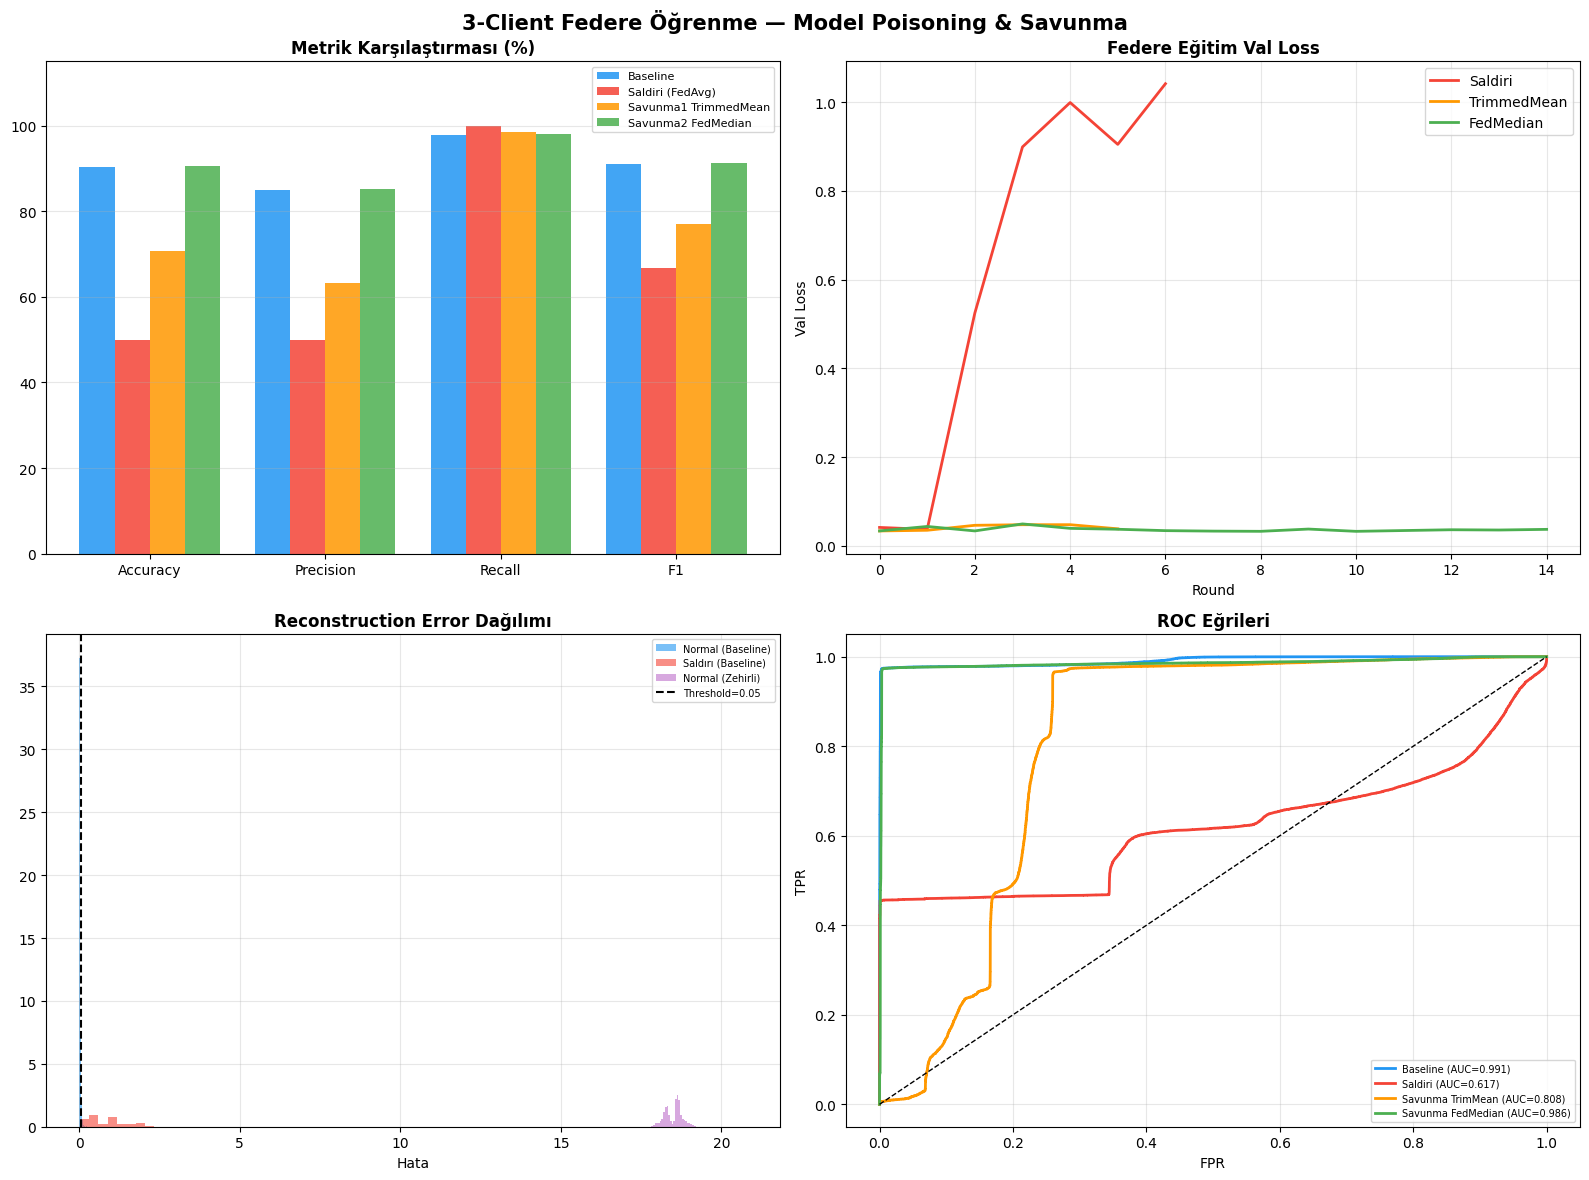

OK Gorsel kaydedildi: /content/drive/MyDrive/federe3Client/poison_savunma_sonuclari/karsilastirma_gorseli_3client.png


In [ ]:
# =============================================================================
# BLOK 8 — KARSILASTIRMA TABLOSU & GORSELLESTIRME
# =============================================================================

print("\n" + "=" * 65)
print("   KARSILASTIRMA TABLOSU (3 CLIENT)")
print("=" * 65)

scenarios = [
    ("Baseline",      metrics_baseline),
    ("Saldiri (FedAvg)", metrics_attack),
    ("Savunma1 TrimmedMean", metrics_tm),
    ("Savunma2 FedMedian",   metrics_med),
]

print(f"\n  {'Senaryo':<26} {'Acc%':>7} {'Prec%':>7} {'Rec%':>7} {'F1%':>7} {'AUC':>7}")
print("  " + "-" * 62)
for name, m in scenarios:
    print(f"  {name:<26} {m['accuracy']*100:>6.2f} {m['precision']*100:>7.2f} "
          f"{m['recall']*100:>7.2f} {m['f1']*100:>7.2f} {m['auc']:>7.4f}")

# Karşılaştırma tablosunu kaydet
import pandas as pd
comparison_df = pd.DataFrame([
    {
        'Senaryo'   : name,
        'Accuracy'  : round(m['accuracy']*100, 2),
        'Precision' : round(m['precision']*100, 2),
        'Recall'    : round(m['recall']*100, 2),
        'F1'        : round(m['f1']*100, 2),
        'AUC'       : round(m['auc'], 4),
    }
    for name, m in scenarios
])
comparison_df.to_csv(f'{RESULTS_DIR}/karsilastirma_3client.csv', index=False)
print(f"\nOK Karsilastirma tablosu kaydedildi: {RESULTS_DIR}/karsilastirma_3client.csv")

# ── Görselleştirme
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("3-Client Federe Öğrenme — Model Poisoning & Savunma", fontsize=15, fontweight='bold')

# 1) Metrik karşılaştırma bar chart
ax = axes[0, 0]
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1']
x = np.arange(len(metrics_names))
width = 0.2
colors = ['#2196F3', '#F44336', '#FF9800', '#4CAF50']
for i, (name, m) in enumerate(scenarios):
    vals = [m['accuracy']*100, m['precision']*100, m['recall']*100, m['f1']*100]
    ax.bar(x + i*width, vals, width, label=name, color=colors[i], alpha=0.85)
ax.set_title('Metrik Karşılaştırması (%)', fontweight='bold')
ax.set_xticks(x + width*1.5); ax.set_xticklabels(metrics_names)
ax.set_ylim(0, 115); ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

# 2) Val loss eğrileri
ax = axes[0, 1]
for (name, _), hist, color in zip(
    [("Saldiri", None), ("TrimmedMean", None), ("FedMedian", None)],
    [hist_attack, hist_defense_tm, hist_defense_med],
    ['#F44336', '#FF9800', '#4CAF50']
):
    ax.plot(hist['val_loss'], label=name, color=color, linewidth=2)
ax.set_title('Federe Eğitim Val Loss', fontweight='bold')
ax.set_xlabel('Round'); ax.set_ylabel('Val Loss')
ax.legend(); ax.grid(alpha=0.3)

# 3) Reconstruction error dağılımı (Baseline vs Saldırı)
ax = axes[1, 0]
ax.hist(metrics_baseline['err_normal'], bins=60, alpha=0.6, label='Normal (Baseline)', color='#2196F3', density=True)
ax.hist(metrics_baseline['err_attack'], bins=60, alpha=0.6, label='Saldırı (Baseline)', color='#F44336', density=True)
ax.hist(metrics_attack['err_normal'],   bins=60, alpha=0.4, label='Normal (Zehirli)',   color='#9C27B0', density=True, linestyle='--')
ax.axvline(FIXED_THRESHOLD, color='black', linestyle='--', linewidth=1.5, label=f'Threshold={FIXED_THRESHOLD}')
ax.set_title('Reconstruction Error Dağılımı', fontweight='bold')
ax.set_xlabel('Hata'); ax.legend(fontsize=7); ax.grid(alpha=0.3)

# 4) ROC eğrileri
ax = axes[1, 1]
for name, m, color in zip(
    ["Baseline", "Saldiri", "Savunma TrimMean", "Savunma FedMedian"],
    [metrics_baseline, metrics_attack, metrics_tm, metrics_med],
    ['#2196F3', '#F44336', '#FF9800', '#4CAF50']
):
    fpr, tpr, _ = roc_curve(m['y_true'], m['y_score'])
    ax.plot(fpr, tpr, label=f"{name} (AUC={m['auc']:.3f})", color=color, linewidth=2)
ax.plot([0,1],[0,1], 'k--', linewidth=1)
ax.set_title('ROC Eğrileri', fontweight='bold')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.legend(fontsize=7); ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(f'{RESULTS_DIR}/karsilastirma_gorseli_3client.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"OK Gorsel kaydedildi: {RESULTS_DIR}/karsilastirma_gorseli_3client.png")

In [ ]:
# =============================================================================
# BLOK 9 — OZET RAPOR & KAYDEDILEN DOSYALAR
# =============================================================================

print("\n" + "=" * 65)
print("   OZET RAPOR — 3 CLIENT SALDIRI & SAVUNMA")
print("=" * 65)

def delta(m_new, m_ref, key):
    return (m_new[key] - m_ref[key]) * (100 if key != 'auc' else 1)

print(f"""
  BASELINE  → Acc: %{metrics_baseline['accuracy']*100:.2f}  |  F1: %{metrics_baseline['f1']*100:.2f}  |  AUC: {metrics_baseline['auc']:.4f}

  SALDIRI   → Acc: %{metrics_attack['accuracy']*100:.2f}  |  F1: %{metrics_attack['f1']*100:.2f}  |  AUC: {metrics_attack['auc']:.4f}
              Delta Acc: {delta(metrics_attack, metrics_baseline, 'accuracy'):+.2f}%  |  Delta F1: {delta(metrics_attack, metrics_baseline, 'f1'):+.2f}%

  SAVUNMA1  → Acc: %{metrics_tm['accuracy']*100:.2f}  |  F1: %{metrics_tm['f1']*100:.2f}  |  AUC: {metrics_tm['auc']:.4f}
  (TrimMean)  Kurtarilan Acc: {delta(metrics_tm, metrics_attack, 'accuracy'):+.2f}%  |  F1: {delta(metrics_tm, metrics_attack, 'f1'):+.2f}%

  SAVUNMA2  → Acc: %{metrics_med['accuracy']*100:.2f}  |  F1: %{metrics_med['f1']*100:.2f}  |  AUC: {metrics_med['auc']:.4f}
  (FedMedian) Kurtarilan Acc: {delta(metrics_med, metrics_attack, 'accuracy'):+.2f}%  |  F1: {delta(metrics_med, metrics_attack, 'f1'):+.2f}%
""")

print("  KAYDEDILEN DOSYALAR:")
import os as _os
for f in sorted(_os.listdir(RESULTS_DIR)):
    fpath = f"{RESULTS_DIR}/{f}"
    size  = _os.path.getsize(fpath)
    unit  = "KB" if size < 1_000_000 else "MB"
    sval  = size/1024 if size < 1_000_000 else size/1_048_576
    print(f"    {f:<55} {sval:>7.1f} {unit}")

print(f"\n  Tum ciktilar: {RESULTS_DIR}")
print("=" * 65)
print("   NOTEBOOK TAMAMLANDI")
print("=" * 65)


   OZET RAPOR — 3 CLIENT SALDIRI & SAVUNMA

  BASELINE  → Acc: %90.25  |  F1: %90.94  |  AUC: 0.9912

  SALDIRI   → Acc: %50.00  |  F1: %66.67  |  AUC: 0.6172
              Delta Acc: -40.24%  |  Delta F1: -24.27%

  SAVUNMA1  → Acc: %70.62  |  F1: %77.01  |  AUC: 0.8080
  (TrimMean)  Kurtarilan Acc: +20.62%  |  F1: +10.34%

  SAVUNMA2  → Acc: %90.49  |  F1: %91.15  |  AUC: 0.9856
  (FedMedian) Kurtarilan Acc: +40.49%  |  F1: +24.48%

  KAYDEDILEN DOSYALAR:
    hist_attack_3client.pkl                                     0.5 KB
    hist_defense_med_3client.pkl                                0.9 KB
    hist_defense_tm_3client.pkl                                 0.4 KB
    initial_weights_3client.pkl                                 5.6 MB
    karsilastirma_3client.csv                                   0.2 KB
    karsilastirma_gorseli_3client.png                         210.0 KB
    metrics_attack_3client.pkl                                  1.4 MB
    metrics_baseline_3client.pkl        

   CONFUSION MATRIX — TUM 4 SENARYO (3 CLIENT)


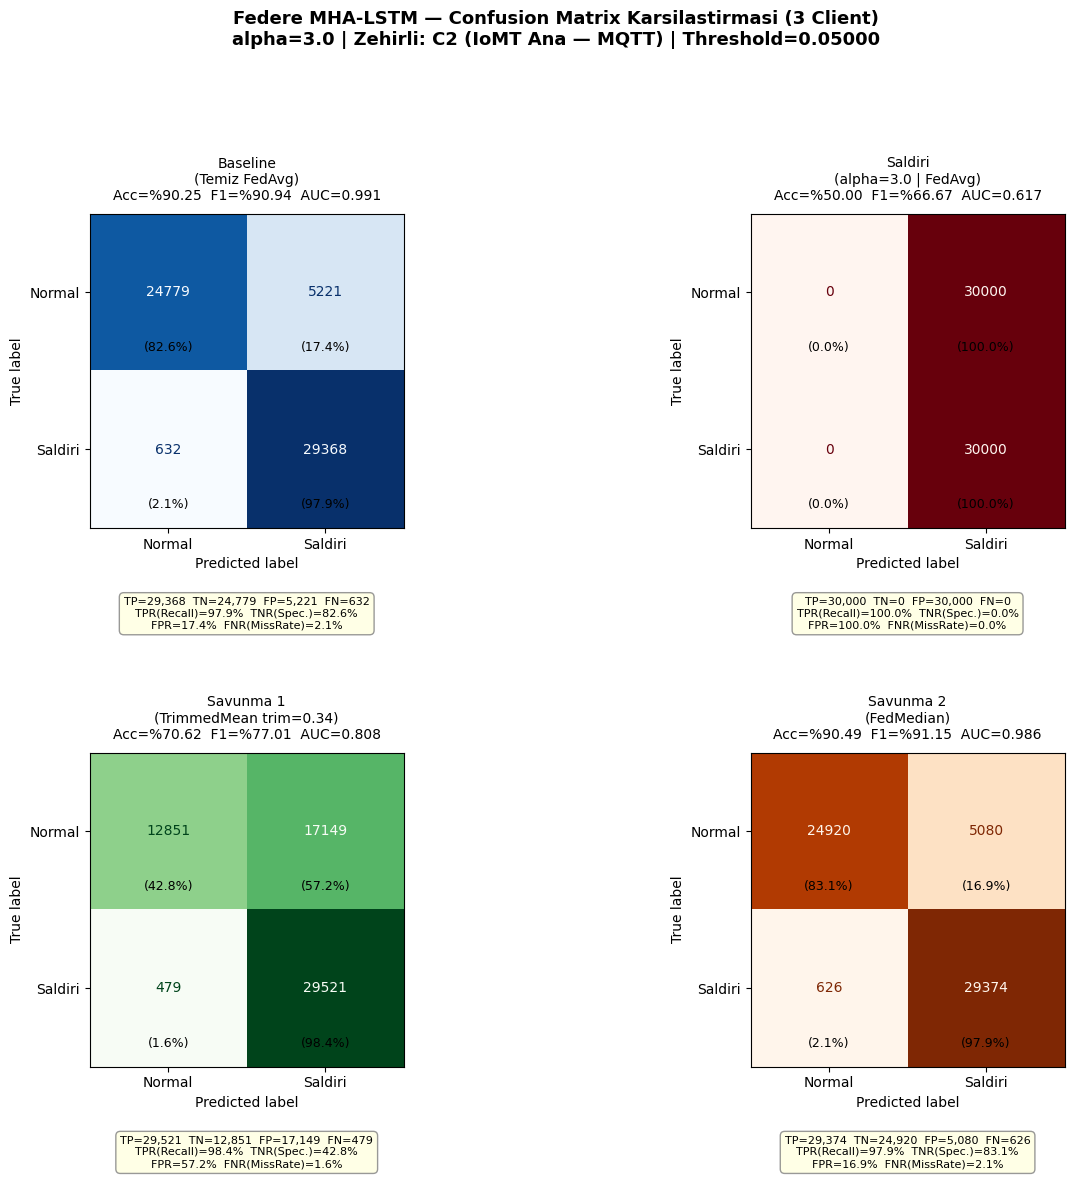

OK Confusion matrix grafigi kaydedildi: /content/drive/MyDrive/federe3Client/poison_savunma_sonuclari/confusion_matrix_4senaryo_3client.png

  Senaryo                             TP      TN      FP      FN    TPR%    FPR%
  ----------------------------------------------------------------------
  Baseline (Temiz FedAvg)         29,368  24,779   5,221     632   97.9%   17.4%
  Saldiri (alpha=3.0 | FedAvg)    30,000       0  30,000       0  100.0%  100.0%
  Savunma 1 (TrimmedMean trim=0.34)  29,521  12,851  17,149     479   98.4%   57.2%
  Savunma 2 (FedMedian)           29,374  24,920   5,080     626   97.9%   16.9%
  TPR = Recall (Saldiriyi dogru yakalama orani)
  FPR = Yanlis alarm orani (Normal trafigi saldiri diye isaretleme)


In [ ]:
# =============================================================================
# BLOK — CONFUSION MATRIX (TUM 4 SENARYO)
# Baseline | Saldiri (FedAvg) | Savunma-TrimmedMean | Savunma-FedMedian
# =============================================================================

print("=" * 65)
print("   CONFUSION MATRIX — TUM 4 SENARYO (3 CLIENT)")
print("=" * 65)

scenarios_cm = [
    ("Baseline\n(Temiz FedAvg)",                    metrics_baseline, 'Blues'),
    (f"Saldiri\n(alpha={ALPHA_POISON} | FedAvg)",   metrics_attack,   'Reds'),
    (f"Savunma 1\n(TrimmedMean trim={TRIM_RATIO})",  metrics_tm,       'Greens'),
    ("Savunma 2\n(FedMedian)",                       metrics_med,      'Oranges'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, (title, metrics, cmap) in enumerate(scenarios_cm):
    ax = axes[i]
    cm = confusion_matrix(metrics['y_true'], metrics['y_pred'])
    tn, fp, fn, tp = cm.ravel()

    # Yuzde hesaplari
    total      = tn + fp + fn + tp
    n_normal   = tn + fp
    n_attack   = fn + tp
    tpr        = tp / n_attack if n_attack > 0 else 0   # Recall / Sensitivity
    tnr        = tn / n_normal if n_normal > 0 else 0   # Specificity
    fpr        = fp / n_normal if n_normal > 0 else 0   # False Positive Rate
    fnr        = fn / n_attack if n_attack > 0 else 0   # Miss Rate

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Normal', 'Saldiri']
    )
    disp.plot(ax=ax, colorbar=False, cmap=cmap, values_format='d')

    # Baslik: senaryo adi + ana metrikler
    ax.set_title(
        f"{title}\n"
        f"Acc=%{metrics['accuracy']*100:.2f}  F1=%{metrics['f1']*100:.2f}  AUC={metrics['auc']:.3f}",
        fontsize=10, pad=10
    )

    # Her hucrenin altina yuzde etiketi
    n_rows, n_cols = cm.shape
    for row in range(n_rows):
        for col in range(n_cols):
            count  = cm[row, col]
            denom  = cm[row, :].sum()
            pct    = count / denom * 100 if denom > 0 else 0
            ax.text(
                col, row + 0.35,
                f"({pct:.1f}%)",
                ha='center', va='center',
                fontsize=9, color='black',
                fontweight='normal'
            )

    # Alt bilgi kutucugu: TP/TN/FP/FN + oranlar
    info = (
        f"TP={tp:,}  TN={tn:,}  FP={fp:,}  FN={fn:,}\n"
        f"TPR(Recall)={tpr*100:.1f}%  TNR(Spec.)={tnr*100:.1f}%\n"
        f"FPR={fpr*100:.1f}%  FNR(MissRate)={fnr*100:.1f}%"
    )
    ax.text(
        0.5, -0.22, info,
        transform=ax.transAxes,
        ha='center', va='top',
        fontsize=8,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow',
                  edgecolor='gray', alpha=0.8)
    )

plt.suptitle(
    f"Federe MHA-LSTM — Confusion Matrix Karsilastirmasi (3 Client)\n"
    f"alpha={ALPHA_POISON} | Zehirli: C2 (IoMT Ana — MQTT) | "
    f"Threshold={FIXED_THRESHOLD:.5f}",
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout(pad=3.0)

cm_path = f'{RESULTS_DIR}/confusion_matrix_4senaryo_3client.png'
fig.savefig(cm_path, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f"OK Confusion matrix grafigi kaydedildi: {cm_path}")

# --- Ozet tablo ---
print("\n" + "=" * 70)
print(f"  {'Senaryo':<30} {'TP':>7} {'TN':>7} {'FP':>7} {'FN':>7} {'TPR%':>7} {'FPR%':>7}")
print("  " + "-" * 70)
for title, metrics, _ in scenarios_cm:
    cm  = confusion_matrix(metrics['y_true'], metrics['y_pred'])
    tn, fp, fn, tp = cm.ravel()
    n_attack = fn + tp
    n_normal = tn + fp
    tpr = tp / n_attack * 100 if n_attack > 0 else 0
    fpr = fp / n_normal * 100 if n_normal > 0 else 0
    short = title.replace('\n', ' ')
    print(f"  {short:<30} {tp:>7,} {tn:>7,} {fp:>7,} {fn:>7,} {tpr:>6.1f}% {fpr:>6.1f}%")
print("=" * 70)
print("  TPR = Recall (Saldiriyi dogru yakalama orani)")
print("  FPR = Yanlis alarm orani (Normal trafigi saldiri diye isaretleme)")
